In [2]:
from langchain.chat_models import init_chat_model
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [4]:
# from langchain_community.chat_models import ChatOllama
from langchain_ollama import ChatOllama

llm_ollama = ChatOllama(
    model="llama3.2",          # must match `ollama pull` name
    base_url="http://localhost:11434",  # default; omit if unchanged
    temperature=0,
)
llm_ollama.invoke("Hello, how many days are in a persian year?")

AIMessage(content='A Persian year is approximately equivalent to the solar year, which has 365.24 days.\n\nIn the Persian calendar, there are 12 months, and each month has either 31 or 30 days. The extra day is added to the month of Esfand (also known as Farvardin) at the end of the year.\n\nSo, a Persian year typically consists of:\n\n- 12 months with 31 or 30 days\n- An additional day added to Esfand at the end of the year\n\nThis results in a total of 355 days in a non-leap year and 365 days in a leap year.', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-01T10:33:03.9848807Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6792789600, 'load_duration': 3818027000, 'prompt_eval_count': 37, 'prompt_eval_duration': 276000000, 'eval_count': 131, 'eval_duration': 2694000000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019de319-3be3-7c13-b6e5-745d139b9381-0', tool_calls=[], invalid_tool_calls=[], usage_

In [5]:
from __future__ import annotations
import logging
from typing import Literal
from langchain.chat_models import init_chat_model
from langchain_community.chat_models import ChatOllama
from langchain_core.language_models.chat_models import BaseChatModel
log = logging.getLogger(__name__)

def get_llm_with_fallback(
    *,
    google_spec: str = "google_genai:gemini-2.5-flash",
    ollama_model: str = "llama3.2",
    ollama_base_url: str = "http://localhost:11434",
) -> tuple[BaseChatModel, Literal["google_genai", "ollama"]]:
    """
    Prefer LangChain Google GenAI; if the first real call fails, use local Ollama.
    Notes:
    - `init_chat_model` alone usually does NOT hit the network; a small `invoke` does.
    - That first ping uses a trivial prompt (minimal tokens).
    """
    google_llm = init_chat_model(google_spec)
    try:
        google_llm.invoke("ping")
        return google_llm, "google_genai"
    except Exception as exc:  # ConnectError, 401/429, etc.
        log.warning("Google LLM unavailable (%s); using Ollama instead.", exc)
    ollama_llm = ChatOllama(
        model=ollama_model,
        base_url=ollama_base_url,
        temperature=0,
    )
    return ollama_llm, "ollama"

In [6]:
def get_llm_response(prompt: str):
    return llm_ollama.invoke(prompt)

get_llm_response("Hello, how many days are in a persian year?")


AIMessage(content='A Persian year is approximately equivalent to the solar year, which has 365.24 days.\n\nIn the Persian calendar, there are 12 months, and each month has either 31 or 30 days. The extra day is added to the month of Esfand (also known as Farvardin) at the end of the year.\n\nSo, a Persian year typically consists of:\n\n- 12 months with 31 or 30 days\n- An additional day added to Esfand at the end of the year\n\nThis results in a total of approximately 355 days in a non-leap year and 365 days in a leap year.', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-01T10:33:07.7148133Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3038641200, 'load_duration': 40028000, 'prompt_eval_count': 37, 'prompt_eval_duration': 4000000, 'eval_count': 132, 'eval_duration': 2993000000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019de319-619d-7031-b85b-735c74b3d244-0', tool_calls=[], invalid_tool_calls=

In [7]:
# MemorySaver is a checkpoint that saves the state of the graph to memory! 
# You provide this function while compiling the graph!
# Then, by invoking the graph, you should provide the config parameter!
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [8]:
class ChatState(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [9]:
# from langchain_core.tools import tool
@tool
def get_stock_price(symbol: str) -> float:
    '''Return the current price of a stock given the stock symbol
    :param symbol: stock symbol
    :return: current price of the stock
    '''
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RIL": 87.6
    }.get(symbol, 0.0)

tools = [get_stock_price]
llm_with_tools = llm_ollama.bind_tools(tools)

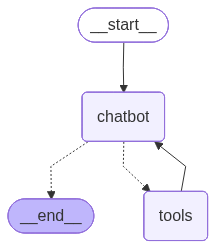

In [10]:
def chatbot(state: ChatState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(ChatState)
builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")

builder.add_edge("chatbot", END)

graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

#Langsmith allows to upload the traces of your call via annotation.

In [13]:
config1 = { 'configurable': { 'thread_id': '1'} }

msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config1)
print(state["messages"][-1].content)

Based on the current stock prices, here are the calculations:

For AMZN (Amazon):
Current price: $150.00
Number of shares to buy: 20
Total cost: 20 x $150.00 = $3000.00

For MSFT (Microsoft):
Current price: $200.30
Number of shares to buy: 15
Total cost: 15 x $200.30 = $3004.50

The total cost for both purchases is: $3000.00 + $3004.50 = $6004.50


In [14]:
from langsmith import traceable

@traceable
def call_graph(query: str):
    state = graph.invoke({"messages": [{"role": "user", "content": query}]}, config=config1)
    return state["messages"][-1].content

call_graph("I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?")

'Based on the current stock prices:\n\nFor AMZN (Amazon):\nCurrent price: $150.00\nNumber of shares to buy: 20\nTotal cost: 20 x $150.00 = $3000.00\n\nFor MSFT (Microsoft):\nCurrent price: $200.30\nNumber of shares to buy: 15\nTotal cost: 15 x $200.30 = $3004.50\n\nThe total cost for both purchases is: $3000.00 + $3004.50 = $6004.50'